# Ekstraksi Fitur Warna dan Tekstur Citra Wajah

## Import Library & Mount Drive

In [2]:
import cv2
import numpy as np
import pandas as pd
import os

from google.colab import drive
drive.mount('/content/drive')

from skimage.feature import graycomatrix, graycoprops

Mounted at /content/drive


## Tentukan Path Dataset

In [ ]:
base_path = "/content/drive/MyDrive/datasets/citra-male-female"

male_path = os.path.join(base_path, "male")
female_path = os.path.join(base_path, "female")

## Fungsi Ekstraksi Fitur HSV

In [ ]:
def extract_hsv(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    h_mean = np.mean(hsv[:,:,0])
    s_mean = np.mean(hsv[:,:,1])
    v_mean = np.mean(hsv[:,:,2])

    return [h_mean, s_mean, v_mean]

## Fungsi Ekstraksi Fitur Tekstur (GLCM)

In [ ]:
def extract_glcm(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0,0]
    correlation = graycoprops(glcm, 'correlation')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

    return [contrast, correlation, energy, homogeneity]

## Loop Semua Gambar + Labeling

In [ ]:
data = []
labels = []

def process_folder(folder_path, label):
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)

        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(image, (58, 58))  # samakan ukuran

        hsv_feat = extract_hsv(image)
        glcm_feat = extract_glcm(image)

        features = hsv_feat + glcm_feat

        data.append(features)
        labels.append(label)

Jalankan untuk Male & Female

In [ ]:
process_folder(male_path, "male")
process_folder(female_path, "female")

## Gabungkan ke DataFrame

In [ ]:
columns = [
    "h_mean", "s_mean", "v_mean",
    "contrast", "correlation", "energy", "homogeneity"
]

df = pd.DataFrame(data, columns=columns)
df["label"] = labels

print("3 data pertama:")
display(df.head(3))
print("\n3 data terakhir:")
display(df.tail(3))

3 data pertama:


,h_mean,s_mean,v_mean,contrast,correlation,energy,homogeneity,label
0,146.635256,43.142093,180.267836,252.042952,0.969749,0.021202,0.149806,male
1,14.199762,107.114447,185.789834,450.358137,0.894740,0.022071,0.134727,male
2,25.746136,79.696492,160.725030,319.527526,0.931651,0.018015,0.119173,male



3 data terakhir:


,h_mean,s_mean,v_mean,contrast,correlation,energy,homogeneity,label
199,11.292509,86.502081,158.615042,256.672414,0.944249,0.020844,0.174150,female
200,43.614447,57.630202,137.431034,228.717181,0.954767,0.017589,0.103133,female
201,12.728597,74.271700,174.576397,250.645191,0.970959,0.019073,0.126241,female


## Export ke CSV

In [ ]:
output_path = "/content/drive/MyDrive/datasets/fitur_citra_wajah.csv"
df.to_csv(output_path, index=False)

print("Berhasil disimpan di:", output_path)

Berhasil disimpan di: /content/drive/MyDrive/datasets/fitur_citra_wajah.csv


# Klasifikasi Gender Berdasarkan Citra Wajah dengan Metode KNN

## Import & Persiapan Data

In [15]:
import cv2, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset hasil ekstraksi
df = pd.read_csv("/content/drive/MyDrive/datasets/fitur_citra_wajah.csv")

X = df.drop("label", axis=1)
y = df["label"]

df.head()

,h_mean,s_mean,v_mean,contrast,correlation,energy,homogeneity,label
0,146.635256,43.142093,180.267836,252.042952,0.969749,0.021202,0.149806,male
1,14.199762,107.114447,185.789834,450.358137,0.894740,0.022071,0.134727,male
2,25.746136,79.696492,160.725030,319.527526,0.931651,0.018015,0.119173,male
3,15.461058,89.050535,144.457491,243.670296,0.959018,0.020221,0.141641,male
4,18.197087,131.656064,151.909929,364.224138,0.957015,0.020384,0.138189,male


##split dataset

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

## Training Model

In [13]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training Model - Hyperparameter tuning for n_neighbors
best_accuracy = 0
best_n_neighbors = 1

for n in range(1, 15): # Trying n_neighbors from 1 to 14
    current_model = KNeighborsClassifier(n_neighbors=n)
    current_model.fit(X_train_scaled, y_train)
    current_y_pred = current_model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, current_y_pred)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_n_neighbors = n

# Train the final model with the best n_neighbors found
model = KNeighborsClassifier(n_neighbors=best_n_neighbors)
model.fit(X_train_scaled, y_train)

print(f"Best n_neighbors found: {best_n_neighbors}")
print(f"Accuracy with best n_neighbors: {best_accuracy}")

# Make predictions with the final model for evaluation
y_pred = model.predict(X_test_scaled)

Best n_neighbors found: 9
Accuracy with best n_neighbors: 0.6097560975609756


## Evaluasi Model


Classification Report:
              precision    recall  f1-score   support

      female       0.57      0.63      0.60        19
        male       0.65      0.59      0.62        22

    accuracy                           0.61        41
   macro avg       0.61      0.61      0.61        41
weighted avg       0.61      0.61      0.61        41



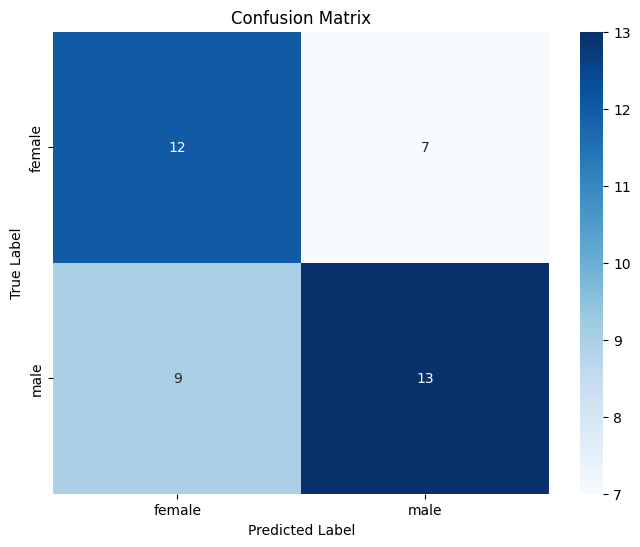

In [8]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
